## Parte 3 — Isolation Forest (Modelo Não Supervisionado)

Modelos não supervisionados, como o Isolation Forest, podem ser eficazes na detecção de fraudes, pois identificam padrões incomuns nos dados. Como fraudes são eventos raros e geralmente apresentam comportamentos distintos, podem ser detectadas como anomalias, mesmo sem o uso de rótulos.

1. Importação de bibliotecas

In [3]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

2. Carregamento do dataset

In [4]:
df = pd.read_csv('../data/creditcard.csv')

3. Separação de variáveis

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

4. Treinamento do modelo Isolation Forest

In [6]:
model_if = IsolationForest(
    n_estimators=100,
    contamination=0.001,  # proporção estimada de fraudes
    random_state=42
)

model_if.fit(X)

IsolationForest(contamination=0.001, random_state=42)

5. Predições

In [7]:
y_pred_if = model_if.predict(X)

In [8]:
y_pred_if = np.where(y_pred_if == -1, 1, 0)

6. Matriz de confusão

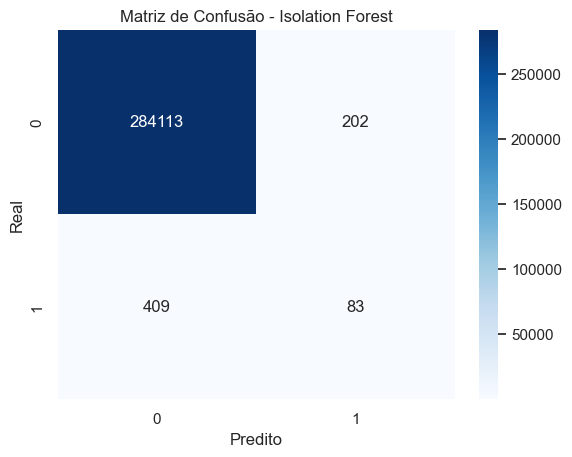

In [9]:
cm_if = confusion_matrix(y, y_pred_if)

sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Isolation Forest')
plt.show()

In [10]:
print(classification_report(y, y_pred_if))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.29      0.17      0.21       492

    accuracy                           1.00    284807
   macro avg       0.64      0.58      0.61    284807
weighted avg       1.00      1.00      1.00    284807



Análise do Isolation Forest

O modelo Isolation Forest teve um desempenho bem inferior na detecção de fraudes quando comparado à regressão logística.

Observando a matriz de confusão, é possível notar um número muito alto de falsos negativos (409), ou seja, a maior parte das fraudes não foi identificada pelo modelo. Isso é um problema crítico nesse tipo de aplicação, já que essas fraudes passariam despercebidas.

Por outro lado, o número de falsos positivos foi relativamente baixo (202), indicando que o modelo não tende a classificar muitas transações normais como fraude. Isso mostra que ele é mais conservador.

Esse comportamento acontece porque o Isolation Forest não utiliza rótulos durante o treinamento. Ele apenas tenta identificar pontos que fogem muito do padrão geral dos dados. No entanto, nem todas as fraudes são extremamente diferentes das transações normais, o que faz com que muitas delas não sejam detectadas.

Com isso, é possível concluir que, apesar de ser útil para identificar anomalias, o Isolation Forest não foi eficiente nesse problema específico de detecção de fraudes, principalmente por não conseguir capturar padrões mais sutis.

7. Variação do parâmetro contamination

Modelo com contamination = 0.01

In [11]:
model_if_01 = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

model_if_01.fit(X)

y_pred_01 = model_if_01.predict(X)
y_pred_01 = np.where(y_pred_01 == -1, 1, 0)

Matriz de confusão (0.01)

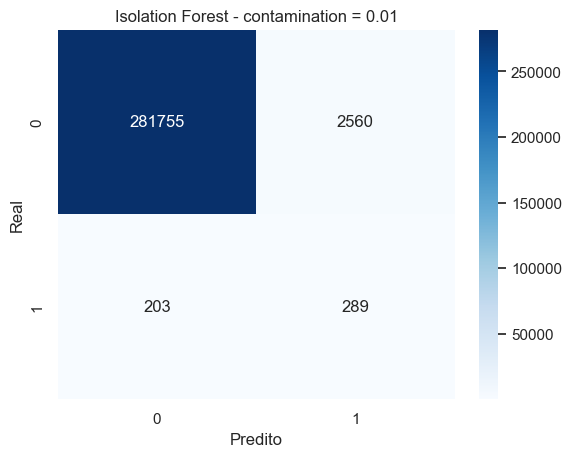

In [12]:
cm_01 = confusion_matrix(y, y_pred_01)

sns.heatmap(cm_01, annot=True, fmt='d', cmap='Blues')
plt.title('Isolation Forest - contamination = 0.01')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Modelo com contamination = 0.05

In [13]:
model_if_05 = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model_if_05.fit(X)

y_pred_05 = model_if_05.predict(X)
y_pred_05 = np.where(y_pred_05 == -1, 1, 0)

Matriz de confusão (0.05)

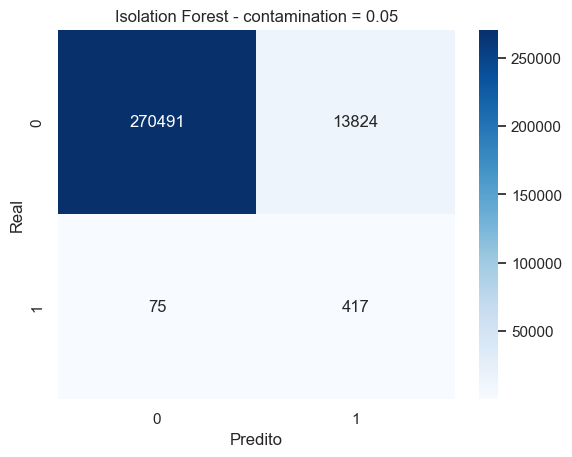

In [14]:
cm_05 = confusion_matrix(y, y_pred_05)

sns.heatmap(cm_05, annot=True, fmt='d', cmap='Blues')
plt.title('Isolation Forest - contamination = 0.05')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Análise do parâmetro contamination

Ao variar o parâmetro contamination, foi possível observar uma mudança clara no comportamento do modelo.

Quando o valor foi aumentado de 0.01 para 0.05, o modelo passou a detectar mais fraudes, reduzindo significativamente o número de falsos negativos (de 203 para 75). Isso mostra que o modelo ficou mais sensível à identificação de anomalias.

No entanto, essa melhoria veio acompanhada de um aumento muito grande nos falsos positivos (de 2560 para 13824), indicando que muitas transações normais passaram a ser classificadas como fraude.

Isso acontece porque o parâmetro contamination define quantos pontos o modelo considera como anomalia. Quanto maior esse valor, mais "agressivo" o modelo se torna, classificando mais transações como suspeitas.

Esse comportamento evidencia novamente o trade-off entre detectar mais fraudes e evitar erros em transações legítimas.

8. Variação do parâmetro n_estimators

Modelo com n_estimators = 50

In [15]:
model_if_50 = IsolationForest(
    n_estimators=50,
    contamination=0.01,
    random_state=42
)

model_if_50.fit(X)

y_pred_50 = model_if_50.predict(X)
y_pred_50 = np.where(y_pred_50 == -1, 1, 0)

Matriz de confusão (50)

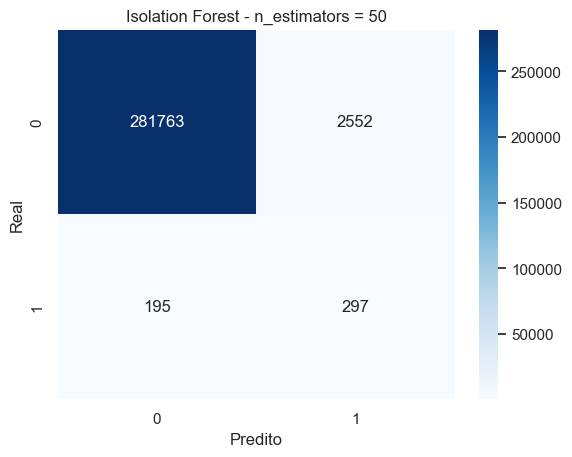

In [16]:
cm_50 = confusion_matrix(y, y_pred_50)

sns.heatmap(cm_50, annot=True, fmt='d', cmap='Blues')
plt.title('Isolation Forest - n_estimators = 50')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Modelo com n_estimators = 200

In [17]:
model_if_200 = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

model_if_200.fit(X)

y_pred_200 = model_if_200.predict(X)
y_pred_200 = np.where(y_pred_200 == -1, 1, 0)

Matriz de confusão (200)

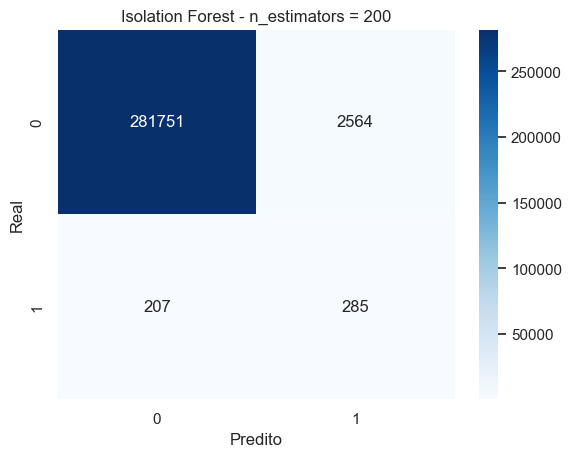

In [19]:
cm_200 = confusion_matrix(y, y_pred_200)

sns.heatmap(cm_200, annot=True, fmt='d', cmap='Blues')
plt.title('Isolation Forest - n_estimators = 200')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Análise do parâmetro n_estimators

Ao variar o número de árvores (n_estimators), foi possível observar que o impacto no desempenho do modelo foi relativamente pequeno.

Comparando os resultados:

- Com n_estimators = 50:
  - Falsos negativos: 195
  - Falsos positivos: 2552

- Com n_estimators = 200:
  - Falsos negativos: 207
  - Falsos positivos: 2564

Os valores são muito próximos, indicando que o aumento no número de árvores não trouxe melhorias significativas na capacidade do modelo de detectar fraudes.

Isso sugere que, para este dataset, o modelo já atinge um nível de estabilidade com um número menor de árvores, e aumentar esse valor não impacta de forma relevante o resultado.

Diferente do parâmetro contamination, que altera diretamente o comportamento do modelo, o n_estimators influencia mais a estabilidade do modelo do que sua capacidade de separação entre classes.

9. Combinação de parâmetros

Nesta etapa, testamos a combinação de diferentes parâmetros para analisar o comportamento conjunto do modelo.

Modelo combinado (n_estimators=200 e contamination=0.05)

In [20]:
model_if_combo = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model_if_combo.fit(X)

y_pred_combo = model_if_combo.predict(X)
y_pred_combo = np.where(y_pred_combo == -1, 1, 0)

Matriz

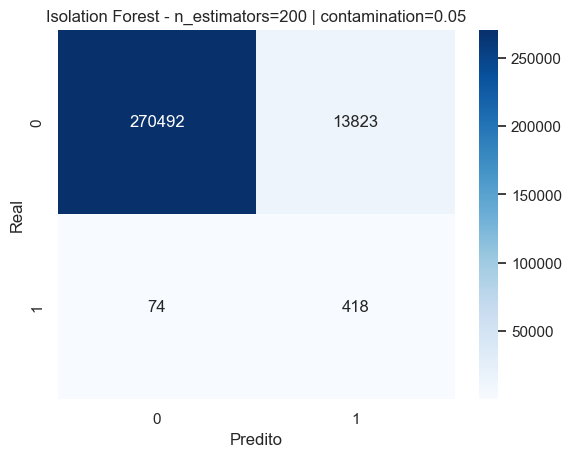

In [21]:
cm_combo = confusion_matrix(y, y_pred_combo)

sns.heatmap(cm_combo, annot=True, fmt='d', cmap='Blues')
plt.title('Isolation Forest - n_estimators=200 | contamination=0.05')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Análise da combinação de parâmetros

Ao combinar os parâmetros n_estimators = 200 e contamination = 0.05, foi possível observar um desempenho muito semelhante ao modelo utilizando apenas o ajuste de contamination.

Os resultados indicam:

- Falsos negativos: 74  
- Falsos positivos: 13823  

Comparando com o modelo anterior (contamination = 0.05), houve uma pequena melhora na detecção de fraudes, com uma leve redução nos falsos negativos (de 75 para 74). No entanto, o número de falsos positivos permaneceu praticamente inalterado.

Isso mostra que o aumento do número de árvores (n_estimators) trouxe apenas um ganho marginal, não alterando significativamente o comportamento geral do modelo.

Dessa forma, fica evidente que o parâmetro contamination é o principal responsável por definir o comportamento do modelo, tornando-o mais ou menos sensível à detecção de anomalias, enquanto o n_estimators atua mais na estabilidade do modelo do que na sua capacidade de classificação.

Essa análise reforça que, embora seja possível ajustar múltiplos parâmetros, nem todos possuem o mesmo impacto no desempenho final.